In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             precision_recall_fscore_support, roc_curve,
                             precision_recall_curve, auc, log_loss)

try:
    import xgboost as xgb
except ImportError:
    xgb = None

print('Imports OK')
print('XGBoost disponible :', xgb is not None)


Imports OK
XGBoost disponible : True


In [2]:
from pathlib import Path

def load_split(split_name):
    data_dir = Path('CICIOT23') / split_name
    csv_files = sorted(data_dir.glob('*.csv'))
    if len(csv_files) == 0:
        raise FileNotFoundError(f'Aucun fichier CSV trouvé dans {data_dir.resolve()}. Placez le dataset CICIoT2023 dans ce dossier.')
    print(f'Chargement {split_name} depuis {data_dir.resolve()} ({len(csv_files)} fichiers)')
    dfs = []
    for p in csv_files:
        print('Lecture de', p.name)
        dfs.append(pd.read_csv(p))
    df = pd.concat(dfs, ignore_index=True)
    print(f'{split_name.capitalize()} chargé : {df.shape}')
    return df

df_train = load_split('train')
df_test = load_split('test')
df_validation = load_split('validation')
print('Colonnes communes :', sorted(set(df_train.columns) & set(df_test.columns) & set(df_validation.columns)))


Chargement train depuis C:\Users\Tareq\Desktop\Tareq\UTC\GI05\SR09\MODELS\CICIOT23\train (1 fichiers)
Lecture de train.csv
Train chargé : (5491971, 47)
Chargement test depuis C:\Users\Tareq\Desktop\Tareq\UTC\GI05\SR09\MODELS\CICIOT23\test (1 fichiers)
Lecture de test.csv
Test chargé : (1176851, 47)
Chargement validation depuis C:\Users\Tareq\Desktop\Tareq\UTC\GI05\SR09\MODELS\CICIOT23\validation (1 fichiers)
Lecture de validation.csv
Validation chargé : (1176851, 47)
Colonnes communes : ['ARP', 'AVG', 'Covariance', 'DHCP', 'DNS', 'Drate', 'Duration', 'HTTP', 'HTTPS', 'Header_Length', 'IAT', 'ICMP', 'IPv', 'IRC', 'LLC', 'Magnitue', 'Max', 'Min', 'Number', 'Protocol Type', 'Radius', 'Rate', 'SMTP', 'SSH', 'Srate', 'Std', 'TCP', 'Telnet', 'Tot size', 'Tot sum', 'UDP', 'Variance', 'Weight', 'ack_count', 'ack_flag_number', 'cwr_flag_number', 'ece_flag_number', 'fin_count', 'fin_flag_number', 'flow_duration', 'label', 'psh_flag_number', 'rst_count', 'rst_flag_number', 'syn_count', 'syn_flag_

## Charger et préparer le dataset CICIoT2023
Le dataset doit être présent localement dans le dossier `CICIOT23/`.
Ce notebook utilise explicitement les splits prédéfinis : `CICIOT23/train`, `CICIOT23/test`, et `CICIOT23/validation`.


## Source de données
Les données sont chargées localement depuis les dossiers `CICIOT23/train`, `CICIOT23/test` et `CICIOT23/validation`.
Ce notebook ne dépend pas d’une URL externe pour le dataset.


## Créer les étiquettes MitM
Nous considérons les flux `DNS spoofing` et `ARP spoofing` comme des attaques MitM, et tout le reste comme normal.
Cette étape construit une colonne binaire `label` pour l'entraînement.

In [3]:
candidate_label_columns = [c for c in df_train.columns if c.lower() in ['label', 'attack', 'category', 'class', 'state', 'flow_type', 'flowtype', 'protocol']]
print('Colonnes candidates pour les labels :', candidate_label_columns)
label_column = None
for col in candidate_label_columns:
    try:
        unique = df_train[col].dropna().unique()
    except Exception:
        continue
    print('  {}: {} catégories -> {}'.format(col, len(unique), list(map(str, unique[:20]))))
    if len(unique) > 1 and label_column is None:
        label_column = col
if label_column is None:
    raise ValueError('Impossible de trouver une colonne de label dans le dataset. Vérifiez les colonnes.')

import re

def normalize_label(value):
    if pd.isna(value):
        return ''
    return str(value).strip().lower()

def is_mitm_label(text):
    if not text:
        return False
    if 'dns' in text and 'spoof' in text:
        return True
    if 'arp' in text and 'spoof' in text:
        return True
    if 'mitm' in text and 'spoof' in text:
        return True
    if re.search(r'(?:arp|dns|mitm).*(?:spoof|spoofing)', text):
        return True
    return False

def is_benign_label(text):
    if not text:
        return False
    return 'benign' in text or 'normal' in text or text in ('benigntraffic', 'benign_traffic', 'normaltraffic')

for name, df in [('train', df_train), ('test', df_test), ('validation', df_validation)]:
    df = df.copy()
    df['label_clean'] = df[label_column].astype(str).apply(normalize_label)
    df['mitm_label'] = df['label_clean'].apply(is_mitm_label).astype(int)
    df['is_benign'] = df['label_clean'].apply(is_benign_label)
    original_len = len(df)
    df = df[df['is_benign'] | (df['mitm_label'] == 1)].copy()
    kept_len = len(df)
    print('[{}] total={} benign={} mitm={} filtered={}'.format(
        name, kept_len, int(df['is_benign'].sum()), int(df['mitm_label'].sum()), original_len - kept_len))
    if kept_len == 0:
        raise ValueError('Aucune ligne conservée pour le split {}. Vérifiez le filtrage des labels.'.format(name))
    if name == 'train':
        df_train = df
    elif name == 'test':
        df_test = df
    else:
        df_validation = df

print('Label column sélectionnée :', label_column)


Colonnes candidates pour les labels : ['label']
  label: 34 catégories -> ['DDoS-ACK_Fragmentation', 'DDoS-SYN_Flood', 'DDoS-PSHACK_Flood', 'Mirai-greeth_flood', 'DoS-SYN_Flood', 'DDoS-ICMP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'Mirai-greip_flood', 'BenignTraffic', 'Mirai-udpplain', 'DoS-TCP_Flood', 'DDoS-SynonymousIP_Flood', 'DoS-UDP_Flood', 'DDoS-RSTFINFlood', 'Recon-HostDiscovery', 'DDoS-UDP_Fragmentation', 'DDoS-ICMP_Fragmentation', 'DDoS-HTTP_Flood', 'MITM-ArpSpoofing']
[train] total=187068 benign=129538 mitm=57530 filtered=5304903
[test] total=40119 benign=27709 mitm=12410 filtered=1136732
[validation] total=39825 benign=27519 mitm=12306 filtered=1137026
Label column sélectionnée : label


## Analyse exploratoire des classes et des features
Exploration de la distribution des classes, des features numériques et des corrélations entre features.

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Number,Magnitue,Radius,Covariance,Variance,Weight,label,label_clean,mitm_label,is_benign
15,27.676334,2232967.2,6.0,114.4,79.110911,79.110911,0.0,0.0,0.0,0.0,...,13.5,38.788308,1011.217735,5.112980e+05,1.0,244.6,BenignTraffic,benigntraffic,0,True
47,0.494425,28347.2,6.0,64.0,60.158974,60.158974,0.0,0.0,0.0,0.0,...,5.5,52.013294,512.069487,1.901665e+05,0.7,38.5,BenignTraffic,benigntraffic,0,True
91,2.401417,497850.4,6.0,114.4,175.937224,175.937224,0.0,0.0,0.0,0.0,...,5.5,72.491546,2639.086822,5.879485e+06,0.7,38.5,BenignTraffic,benigntraffic,0,True
115,35.177868,30327.6,6.0,148.8,7.164333,7.164333,0.0,0.0,0.0,0.0,...,5.5,19.433313,291.173369,5.321982e+04,0.9,38.5,BenignTraffic,benigntraffic,0,True
160,189.543228,40787.7,8.2,62.5,25.292233,25.292233,0.0,0.0,0.0,0.0,...,13.5,46.016565,1762.840665,1.555844e+06,1.0,244.6,BenignTraffic,benigntraffic,0,True


Répartition des labels sur les splits :
  train: {0: 129538, 1: 57530}, ratio mitm=0.3075
  test: {0: 27709, 1: 12410}, ratio mitm=0.3093
  validation: {0: 27519, 1: 12306}, ratio mitm=0.3090
Top labels sur le train :


label_clean
benigntraffic       129538
mitm-arpspoofing     36316
dns_spoofing         21214
Name: count, dtype: int64

Types de colonnes :
float64    46
str         2
int32       1
bool        1
Name: count, dtype: int64
Statistiques numériques (train) :


,count,mean,std,min,25%,50%,75%,max
flow_duration,187068.0,7.933025e+01,9.811542e+02,0.000000e+00,5.479169,2.111644e+01,5.000246e+01,5.952549e+04
Header_Length,187068.0,1.165851e+06,1.614959e+06,0.000000e+00,67162.025000,5.231539e+05,1.584220e+06,9.890105e+06
Protocol Type,187068.0,8.027046e+00,3.123831e+00,0.000000e+00,6.000000,6.600000e+00,9.200000e+00,1.700000e+01
Duration,187068.0,1.098750e+02,5.165420e+01,0.000000e+00,64.000000,9.430000e+01,1.370000e+02,2.494000e+02
Rate,187068.0,1.948557e+03,1.972157e+04,4.178550e-03,25.580701,5.902357e+01,1.097586e+02,1.468007e+06
Srate,187068.0,1.948557e+03,1.972157e+04,4.178550e-03,25.580701,5.902357e+01,1.097586e+02,1.468007e+06
Drate,187068.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
fin_flag_number,187068.0,5.880215e-05,7.668051e-03,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
syn_flag_number,187068.0,2.084803e-04,1.443738e-02,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
rst_flag_number,187068.0,1.817521e-04,1.348036e-02,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.000000e+00


Colonnes numériques : 46


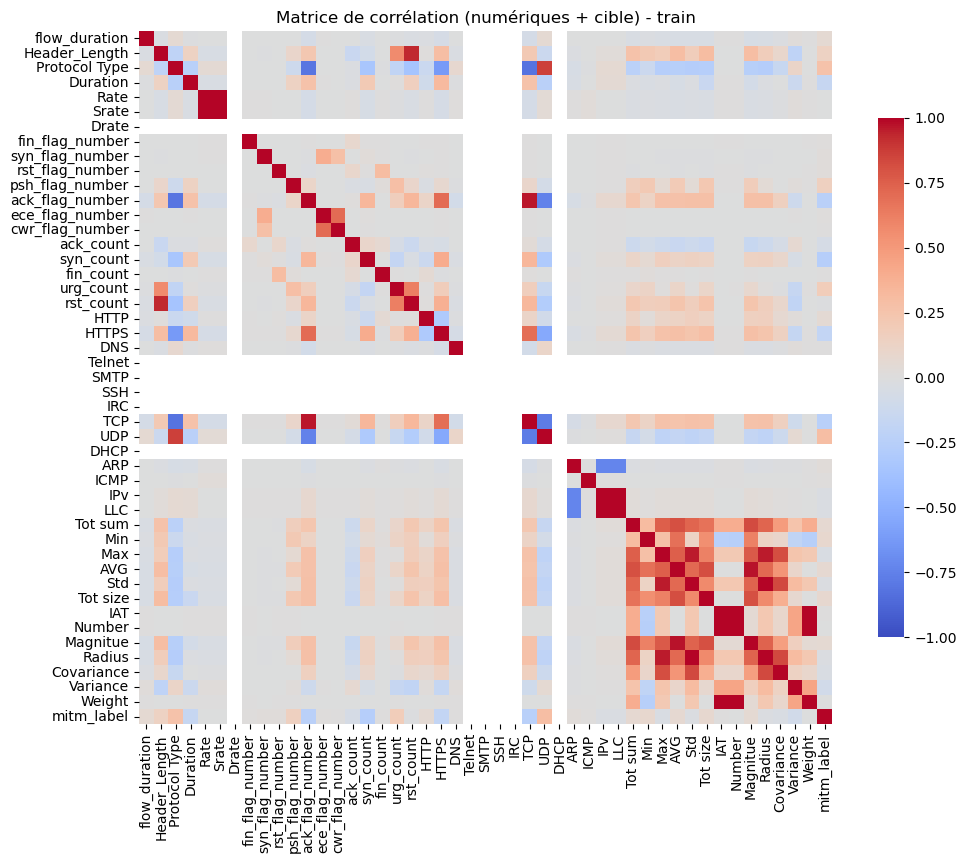

Top 20 des corrélations absolues avec la cible MitM :


mitm_label         1.000000
UDP                0.290364
syn_count          0.263305
Protocol Type      0.259881
TCP                0.244079
ack_flag_number    0.237895
urg_count          0.184679
HTTPS              0.184310
Duration           0.156671
psh_flag_number    0.155293
Header_Length      0.139395
Variance           0.091138
Min                0.080124
Tot size           0.070870
AVG                0.069931
Tot sum            0.063850
flow_duration      0.061218
Magnitue           0.059165
ack_count          0.058351
HTTP               0.053327
Name: mitm_label, dtype: float64

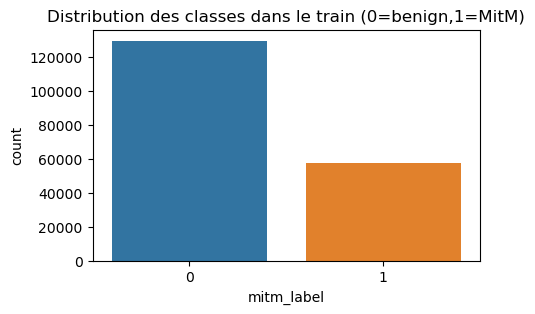

In [4]:
display(df_train.head(5))
print('Répartition des labels sur les splits :')
for split_name, df in [('train', df_train), ('test', df_test), ('validation', df_validation)]:
    counts = df['mitm_label'].value_counts().to_dict()
    print('  {}: {}, ratio mitm={:.4f}'.format(split_name, counts, df['mitm_label'].mean()))

print('Top labels sur le train :')
display(df_train['label_clean'].value_counts().head(20))

print('Types de colonnes :')
print(df_train.dtypes.value_counts())
print('Statistiques numériques (train) :')
display(df_train.describe().T)

numeric_cols = df_train.select_dtypes(include=['number']).columns.tolist()
if 'mitm_label' in numeric_cols:
    numeric_cols.remove('mitm_label')
print('Colonnes numériques :', len(numeric_cols))

if len(numeric_cols) > 1:
    corr = df_train[numeric_cols + ['mitm_label']].corr()
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.75})
    plt.title('Matrice de corrélation (numériques + cible) - train')
    plt.show()
    top_corr = corr['mitm_label'].abs().sort_values(ascending=False).head(20)
    print('Top 20 des corrélations absolues avec la cible MitM :')
    display(top_corr)
else:
    print('Pas assez de colonnes numériques pour calculer la corrélation.')

plt.figure(figsize=(5, 3))
sns.countplot(x='mitm_label', data=df_train)
plt.title('Distribution des classes dans le train (0=benign,1=MitM)')
plt.show()


## Prétraitement et sélection de features
Imputation, encodage des catégorielles, normalisation et préparation du jeu de données.

In [5]:
df_train_model = df_train.copy()
df_test_model = df_test.copy()
df_validation_model = df_validation.copy()

# Colonnes à supprimer (identifiants, timestamps, IPs, labels bruts)
drop_candidates = [
    'flow_id', 'id', 'source_ip', 'dest_ip', 'ip_src', 'ip_dst', 'sourceaddress', 'destinationaddress',
    'timestamp', 'date', 'time', 'label'
]
drop_existing = [c for c in drop_candidates if c in df_train_model.columns]
print('Suppression de colonnes inutiles :', drop_existing)
for df_ in [df_train_model, df_test_model, df_validation_model]:
    df_.drop(columns=drop_existing, inplace=True, errors='ignore')
    df_.drop(columns=[label_column, 'label_clean', 'is_benign'], inplace=True, errors='ignore')

cat_cols = df_train_model.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_train_model.select_dtypes(include=['number']).columns.tolist()
if 'mitm_label' in num_cols:
    num_cols.remove('mitm_label')
print('Colonnes catégorielles :', cat_cols)
print('Colonnes numériques :', len(num_cols))

# Imputation numérique basée sur le train
median_values = df_train_model[num_cols].median()
for df_ in [df_train_model, df_test_model, df_validation_model]:
    df_[num_cols] = df_[num_cols].fillna(median_values)

# Supprimer colonnes à faible variance sur le train et appliquer au test/val
std = df_train_model[num_cols].std()
low_var = std[std < 1e-4].index.tolist()
if low_var:
    print('Suppression variables faible variance :', low_var)
for df_ in [df_train_model, df_test_model, df_validation_model]:
    df_.drop(columns=low_var, inplace=True, errors='ignore')

# Supprimer features fortement corrélées sur le train
num_cols = [c for c in df_train_model.select_dtypes(include=['number']).columns.tolist() if c != 'mitm_label']
if len(num_cols) > 1:
    corr = df_train_model[num_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    if to_drop:
        print('Suppression features fortement corrélées (>0.95):', to_drop)
    for df_ in [df_train_model, df_test_model, df_validation_model]:
        df_.drop(columns=to_drop, inplace=True, errors='ignore')

# Encodage des catégorielles avec alignement train/test/validation
for c in list(cat_cols):
    if c not in df_train_model.columns:
        continue
    n_unique = df_train_model[c].nunique()
    if n_unique <= 10:
        dtrain = pd.get_dummies(df_train_model[c], prefix=c, drop_first=True)
        dtest = pd.get_dummies(df_test_model[c], prefix=c, drop_first=True)
        dval = pd.get_dummies(df_validation_model[c], prefix=c, drop_first=True)
        all_cols = sorted(set(dtrain.columns) | set(dtest.columns) | set(dval.columns))
        dtrain = dtrain.reindex(columns=all_cols, fill_value=0)
        dtest = dtest.reindex(columns=all_cols, fill_value=0)
        dval = dval.reindex(columns=all_cols, fill_value=0)
        df_train_model = pd.concat([df_train_model.drop(columns=[c], errors='ignore'), dtrain], axis=1)
        df_test_model = pd.concat([df_test_model.drop(columns=[c], errors='ignore'), dtest], axis=1)
        df_validation_model = pd.concat([df_validation_model.drop(columns=[c], errors='ignore'), dval], axis=1)
    else:
        freq = df_train_model[c].value_counts(normalize=True)
        df_train_model[c + '_freq'] = df_train_model[c].map(freq).fillna(0)
        df_test_model[c + '_freq'] = df_test_model[c].map(freq).fillna(0)
        df_validation_model[c + '_freq'] = df_validation_model[c].map(freq).fillna(0)
        for df_ in [df_train_model, df_test_model, df_validation_model]:
            df_.drop(columns=[c], inplace=True, errors='ignore')

# Nettoyage final et alignement des colonnes
for df_ in [df_train_model, df_test_model, df_validation_model]:
    df_.fillna(0, inplace=True)

feature_cols = [c for c in df_train_model.columns if c != 'mitm_label']
print('Nombre de features après prétraitement :', len(feature_cols))

for df_ in [df_test_model, df_validation_model]:
    for c in feature_cols:
        if c not in df_.columns:
            df_[c] = 0

# Aligner l'ordre des colonnes sur le train
feature_cols = sorted(feature_cols)
df_train_model = df_train_model[feature_cols + ['mitm_label']]
df_test_model = df_test_model[feature_cols + ['mitm_label']]
df_validation_model = df_validation_model[feature_cols + ['mitm_label']]

FEATURES = feature_cols
X_train = df_train_model[feature_cols].values
y_train = df_train_model['mitm_label'].values
X_test = df_test_model[feature_cols].values
y_test = df_test_model['mitm_label'].values
X_val = df_validation_model[feature_cols].values
y_val = df_validation_model['mitm_label'].values


Suppression de colonnes inutiles : ['label']
Colonnes catégorielles : []
Colonnes numériques : 46
Suppression variables faible variance : ['Drate', 'Telnet', 'SMTP', 'SSH', 'IRC', 'DHCP']
Suppression features fortement corrélées (>0.95): ['Srate', 'TCP', 'LLC', 'Std', 'Number', 'Magnitue', 'Radius', 'Weight']
Nombre de features après prétraitement : 32


## Séparation train/test et normalisation
Création d'un split stratifié et application d'un scaler pour les modèles qui en ont besoin.

In [6]:
if len(X_train) < 10:
    raise ValueError('Taille du jeu de données trop petite pour un entraînement fiable: ' + str(len(X_train)))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print(f'Train : {X_train.shape[0]} lignes, Test : {X_test.shape[0]} lignes, Validation : {X_val.shape[0]} lignes')
print('Taux attaque train :', round(y_train.mean(), 6))
print('Taux attaque test  :', round(y_test.mean(), 6))
print('Taux attaque val   :', round(y_val.mean(), 6))


Train : 187068 lignes, Test : 40119 lignes, Validation : 39825 lignes
Taux attaque train : 0.307535
Taux attaque test  : 0.30933
Taux attaque val   : 0.309002


## Entraîner un Random Forest
Un modèle robuste pour démarrer, avec `class_weight='balanced'`.

Random Forest - classification report
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97     27709
        MitM       0.97      0.89      0.93     12410

    accuracy                           0.96     40119
   macro avg       0.96      0.94      0.95     40119
weighted avg       0.96      0.96      0.96     40119

ROC-AUC: 0.990485516433613


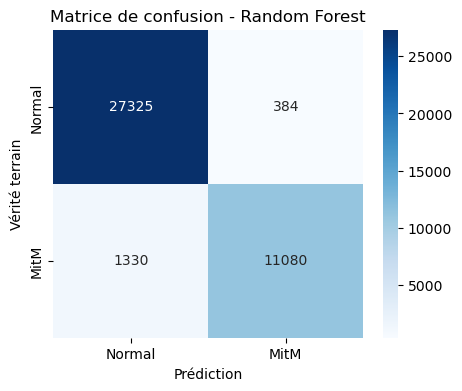

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
try:
    y_pred_rf = rf.predict(X_test)
except Exception as e:
    print('Erreur lors de la prédiction RF:', e)
    y_pred_rf = np.zeros(len(X_test), dtype=int)

# probabilités si disponibles
if hasattr(rf, 'predict_proba'):
    y_proba_rf = rf.predict_proba(X_test)[:, 1]
else:
    y_proba_rf = None

print('Random Forest - classification report')
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'MitM']))
if y_proba_rf is not None and len(np.unique(y_test)) > 1:
    try:
        print('ROC-AUC:', roc_auc_score(y_test, y_proba_rf))
    except Exception as e:
        print('Impossible de calculer ROC-AUC RF:', e)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'MitM'], yticklabels=['Normal', 'MitM'])
ax.set_title('Matrice de confusion - Random Forest')
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité terrain')
plt.show()

## Entraîner un XGBoost
Utiliser `scale_pos_weight` pour prendre en compte le déséquilibre.

scale_pos_weight = 2.251660003476447
XGBoost - classification report
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97     27709
        MitM       0.92      0.93      0.92     12410

    accuracy                           0.95     40119
   macro avg       0.94      0.95      0.95     40119
weighted avg       0.95      0.95      0.95     40119

ROC-AUC: 0.9909477495610315


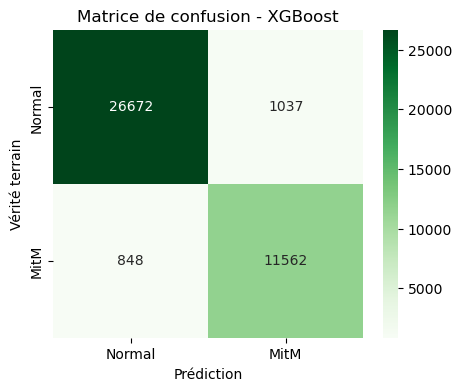

In [8]:
if xgb is None:
    raise ImportError('XGBoost n\'est pas installé. Installez-le avec pip install xgboost.')

ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print('scale_pos_weight =', ratio)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
# Utiliser les données non-scalées ou scaled pour XGBoost: XGBoost gère généralement bien les features non-scalées
xgb_model.fit(X_train, y_train)

try:
    y_pred_xgb = xgb_model.predict(X_test)
    y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
except Exception as e:
    print('Erreur lors de la prédiction XGBoost:', e)
    y_pred_xgb = np.zeros(len(X_test), dtype=int)
    y_proba_xgb = None

print('XGBoost - classification report')
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'MitM']))
if y_proba_xgb is not None and len(np.unique(y_test)) > 1:
    try:
        print('ROC-AUC:', roc_auc_score(y_test, y_proba_xgb))
    except Exception as e:
        print('Impossible de calculer ROC-AUC XGBoost:', e)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Normal', 'MitM'], yticklabels=['Normal', 'MitM'])
ax.set_title('Matrice de confusion - XGBoost')
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité terrain')
plt.show()

In [9]:
summary = {
    'RandomForest': {
        'F1_Macro': precision_recall_fscore_support(y_test, y_pred_rf, average='macro')[2],
        'F1_Mitm': precision_recall_fscore_support(y_test, y_pred_rf, average=None)[2][1] if len(np.unique(y_test))>1 else np.nan,
        'ROC_AUC': roc_auc_score(y_test, y_proba_rf) if (y_proba_rf is not None and len(np.unique(y_test))>1) else np.nan
    },
    'XGBoost': {
        'F1_Macro': precision_recall_fscore_support(y_test, y_pred_xgb, average='macro')[2],
        'F1_Mitm': precision_recall_fscore_support(y_test, y_pred_xgb, average=None)[2][1] if len(np.unique(y_test))>1 else np.nan,
        'ROC_AUC': roc_auc_score(y_test, y_proba_xgb) if (y_proba_xgb is not None and len(np.unique(y_test))>1) else np.nan
    }
}
summary_df = pd.DataFrame(summary).T.round(4)
display(summary_df)

,F1_Macro,F1_Mitm,ROC_AUC
RandomForest,0.9489,0.9282,0.9905
XGBoost,0.9452,0.9246,0.9909


## Analyse de surapprentissage et graphiques de généralisation
Cette section compare les performances d'entraînement et de test pour détecter un éventuel surapprentissage.
Les courbes ROC et Precision-Recall sont tracées pour les deux modèles, avec un bilan des écart de performance.


In [10]:
feature_names = [c for c in df_train_model.columns if c != 'mitm_label']
models = {'RandomForest': rf, 'XGBoost': xgb_model}
summary_overfit = []
for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_val_pred = model.predict(X_val)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]
    summary_overfit.append({
        'Model': name,
        'Train_F1_Macro': precision_recall_fscore_support(y_train, y_train_pred, average='macro')[2],
        'Test_F1_Macro': precision_recall_fscore_support(y_test, y_test_pred, average='macro')[2],
        'Validation_F1_Macro': precision_recall_fscore_support(y_val, y_val_pred, average='macro')[2],
        'Train_ROC_AUC': roc_auc_score(y_train, y_train_proba) if len(np.unique(y_train)) > 1 else np.nan,
        'Test_ROC_AUC': roc_auc_score(y_test, y_test_proba) if len(np.unique(y_test)) > 1 else np.nan,
        'Validation_ROC_AUC': roc_auc_score(y_val, y_val_proba) if len(np.unique(y_val)) > 1 else np.nan,
        'Delta_F1_Test': precision_recall_fscore_support(y_train, y_train_pred, average='macro')[2] - precision_recall_fscore_support(y_test, y_test_pred, average='macro')[2],
        'Delta_F1_Val': precision_recall_fscore_support(y_train, y_train_pred, average='macro')[2] - precision_recall_fscore_support(y_val, y_val_pred, average='macro')[2],
        'Delta_ROC_AUC_Test': (roc_auc_score(y_train, y_train_proba) if len(np.unique(y_train)) > 1 else np.nan) - (roc_auc_score(y_test, y_test_proba) if len(np.unique(y_test)) > 1 else np.nan),
        'Delta_ROC_AUC_Val': (roc_auc_score(y_train, y_train_proba) if len(np.unique(y_train)) > 1 else np.nan) - (roc_auc_score(y_val, y_val_proba) if len(np.unique(y_val)) > 1 else np.nan),
    })
summary_overfit_df = pd.DataFrame(summary_overfit).set_index('Model')
display(summary_overfit_df.round(4))


,Train_F1_Macro,Test_F1_Macro,Validation_F1_Macro,Train_ROC_AUC,Test_ROC_AUC,Validation_ROC_AUC,Delta_F1_Test,Delta_F1_Val,Delta_ROC_AUC_Test,Delta_ROC_AUC_Val
Model,,,,,,,,,,
RandomForest,1.0000,0.9489,0.9492,1.0000,0.9905,0.9909,0.0511,0.0508,0.0095,0.0091
XGBoost,0.9715,0.9452,0.9471,0.9975,0.9909,0.9912,0.0263,0.0244,0.0065,0.0062


### Résumé des métriques par modèle
Le tableau ci‑dessous présente F1 (macro) et AUC sur train/test/validation ainsi que les deltas (train - test / val).
Interprétez les deltas positifs comme une baisse de performance hors échantillon (surapprentissage potentiel).


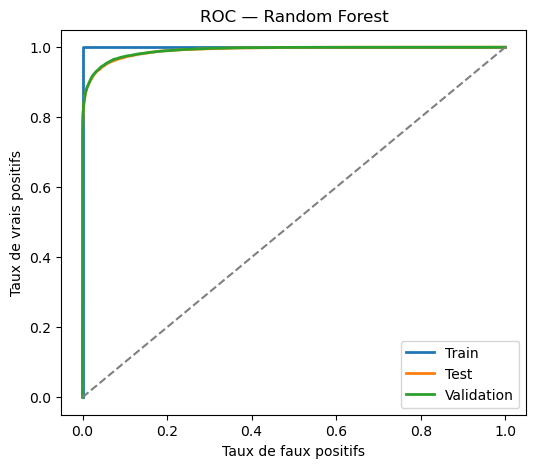

In [17]:
# Courbe ROC pour RandomForest
model = models['RandomForest']
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]
y_val_proba = model.predict_proba(X_val)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label='Train', linewidth=2)
plt.plot(fpr_test, tpr_test, label='Test', linewidth=2)
plt.plot(fpr_val, tpr_val, label='Validation', linewidth=2)
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('ROC — Random Forest')
plt.legend()
plt.show()


**Interprétation ROC — RandomForest**
- Une AUC proche de 1 indique une séparation bonne entre classes.
- Comparez les courbes train/test/validation : si la courbe train est nettement au-dessus, c’est un signe d’overfitting.


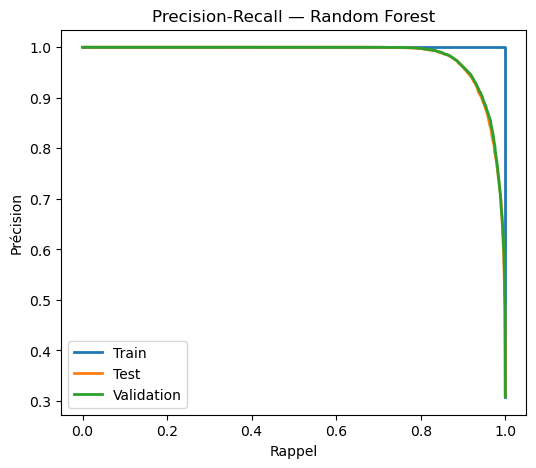

In [18]:
# Courbe Precision-Recall pour RandomForest
model = models['RandomForest']
precision_train, recall_train, _ = precision_recall_curve(y_train, model.predict_proba(X_train)[:,1])
precision_test, recall_test, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])
precision_val, recall_val, _ = precision_recall_curve(y_val, model.predict_proba(X_val)[:,1])
plt.figure(figsize=(6,5))
plt.plot(recall_train, precision_train, label='Train', linewidth=2)
plt.plot(recall_test, precision_test, label='Test', linewidth=2)
plt.plot(recall_val, precision_val, label='Validation', linewidth=2)
plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.title('Precision-Recall — Random Forest')
plt.legend()
plt.show()


**Interprétation PR — RandomForest**
- La PR est informative quand les classes sont déséquilibrées.
- Regardez la précision obtenue aux valeurs de rappel qui vous importent (ex: rappel >= 0.9).


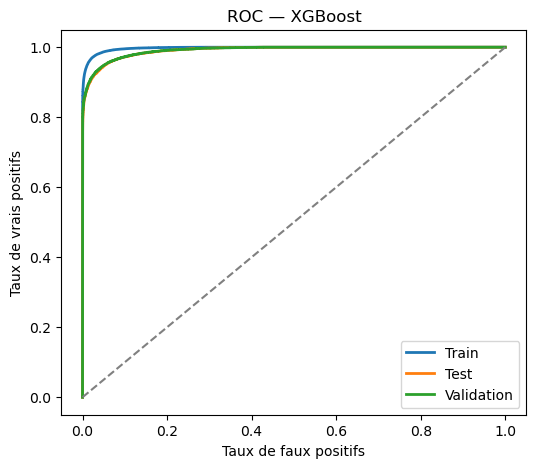

In [19]:
# Courbe ROC pour XGBoost
model = models['XGBoost']
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]
y_val_proba = model.predict_proba(X_val)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label='Train', linewidth=2)
plt.plot(fpr_test, tpr_test, label='Test', linewidth=2)
plt.plot(fpr_val, tpr_val, label='Validation', linewidth=2)
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('ROC — XGBoost')
plt.legend()
plt.show()


**Interprétation ROC — XGBoost**
- Une AUC proche de 1 indique une séparation bonne entre classes.
- Comparez les courbes train/test/validation : si la courbe train est nettement au-dessus, c’est un signe d’overfitting.


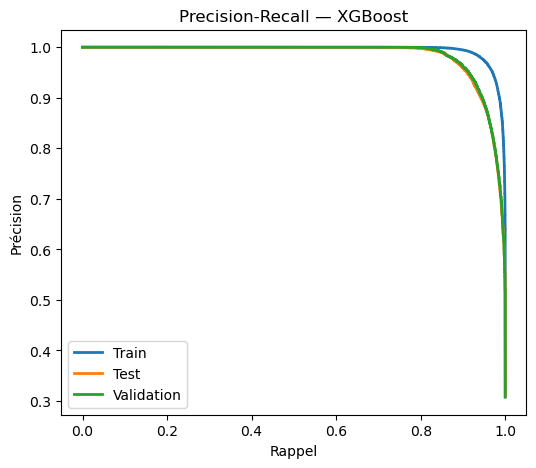

In [20]:
# Courbe Precision-Recall pour XGBoost
model = models['XGBoost']
precision_train, recall_train, _ = precision_recall_curve(y_train, model.predict_proba(X_train)[:,1])
precision_test, recall_test, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])
precision_val, recall_val, _ = precision_recall_curve(y_val, model.predict_proba(X_val)[:,1])
plt.figure(figsize=(6,5))
plt.plot(recall_train, precision_train, label='Train', linewidth=2)
plt.plot(recall_test, precision_test, label='Test', linewidth=2)
plt.plot(recall_val, precision_val, label='Validation', linewidth=2)
plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.title('Precision-Recall — XGBoost')
plt.legend()
plt.show()


**Interprétation PR — XGBoost**
- La PR est informative quand les classes sont déséquilibrées.
- Regardez la précision obtenue aux valeurs de rappel qui vous importent (ex: rappel >= 0.9).


,RandomForest,XGBoost
IAT,0.2936,0.3860
Rate,0.1070,0.0455
flow_duration,0.0889,0.0350
urg_count,0.0873,0.0396
rst_count,0.0740,0.0389
Header_Length,0.0448,0.0226
Variance,0.0391,0.0414
syn_count,0.0380,0.0358
Protocol Type,0.0304,0.0158
Duration,0.0292,0.0135


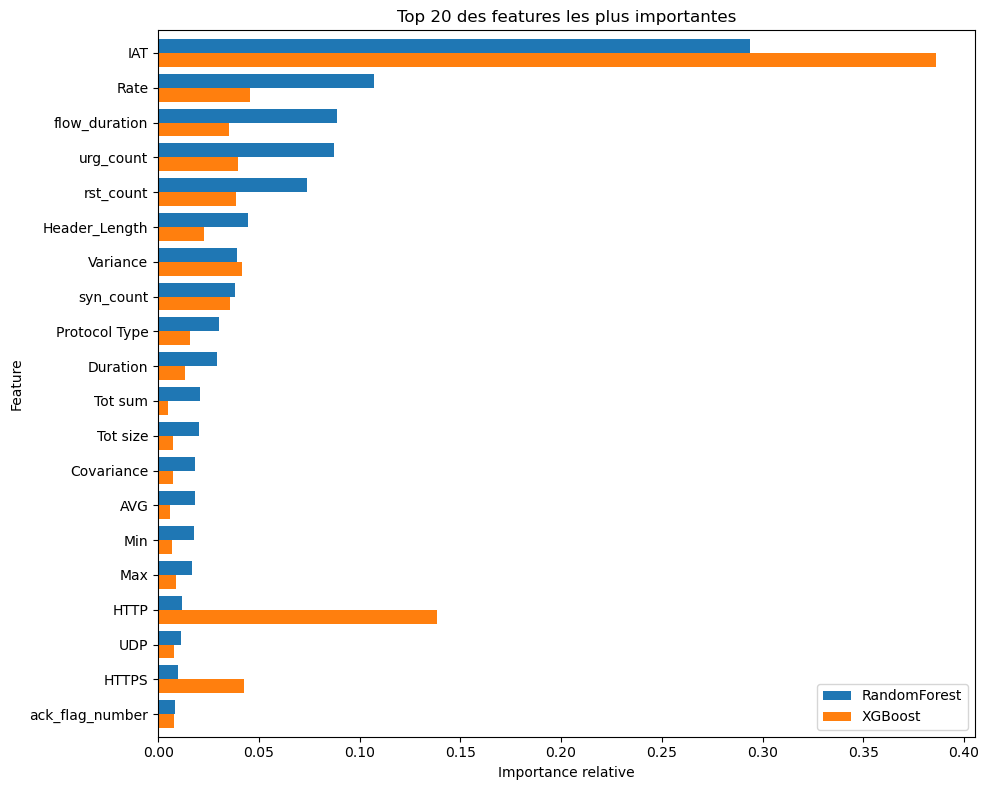

In [21]:
# Importances des features (table + barplot)
feature_importances = pd.DataFrame({
    'RandomForest': rf.feature_importances_,
    'XGBoost': xgb_model.feature_importances_,
}, index=feature_names)
feature_importances = feature_importances.sort_values(by='RandomForest', ascending=False)
top_n = min(20, len(feature_importances))
display(feature_importances.head(top_n).round(4))
ax = feature_importances.head(top_n).plot(kind='barh', figsize=(10,8), width=0.8)
ax.invert_yaxis()
plt.title('Top 20 des features les plus importantes')
plt.xlabel('Importance relative')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Interprétation Importances**
- Les features en tête (IAT, Rate, flow_duration, etc.) contribuent le plus à la décision du modèle.
- Ces variables méritent une inspection plus fine (boxplots, transformation, robust scaling).


In [16]:
# Afficher les deltas et commentaire final
for name in summary_overfit_df.index:
    delta_f1_test = summary_overfit_df.loc[name, 'Delta_F1_Test']
    delta_f1_val = summary_overfit_df.loc[name, 'Delta_F1_Val']
    delta_auc_test = summary_overfit_df.loc[name, 'Delta_ROC_AUC_Test']
    delta_auc_val = summary_overfit_df.loc[name, 'Delta_ROC_AUC_Val']
    print(f'{name}: ΔF1 test={delta_f1_test:.4f}, ΔF1 val={delta_f1_val:.4f}, ΔROC_AUC test={delta_auc_test:.4f}, ΔROC_AUC val={delta_auc_val:.4f}')
    if abs(delta_f1_test) > 0.10 or abs(delta_f1_val) > 0.10 or abs(delta_auc_test) > 0.10 or abs(delta_auc_val) > 0.10:
        print('  -> Attention : écart important entre entraînement et test/validation, signe possible de surapprentissage.')
    elif abs(delta_f1_test) > 0.05 or abs(delta_f1_val) > 0.05 or abs(delta_auc_test) > 0.05 or abs(delta_auc_val) > 0.05:
        print('  -> Écart modéré entre entraînement et test/validation ; surveiller la généralisation.')
    else:
        print('  -> Écart faible entre entraînement et test/validation ; surapprentissage peu probable.')


RandomForest: ΔF1 test=0.0511, ΔF1 val=0.0508, ΔROC_AUC test=0.0095, ΔROC_AUC val=0.0091
  -> Écart modéré entre entraînement et test/validation ; surveiller la généralisation.
XGBoost: ΔF1 test=0.0263, ΔF1 val=0.0244, ΔROC_AUC test=0.0065, ΔROC_AUC val=0.0062
  -> Écart faible entre entraînement et test/validation ; surapprentissage peu probable.


**Conclusion synthétique**
- RandomForest: léger surapprentissage observé (delta F1 ~0.05).
- XGBoost: meilleure généralisation (delta plus faible).
- Recommandations : réduire complexité RF, cross-validation, régularisation XGBoost.


## Analyse de surapprentissage et graphiques pour publication
Cette section compare les performances d’entraînement et de test, trace les courbes ROC/PR,
et affiche les importances des features pour mieux documenter les résultats dans un papier.


## Interprétation des graphes

Cette section explique chaque graphique généré précédemment : ROC, PR, distribution des classes et importances de features.

- **ROC / AUC :** valeur près de 0.99 indique une excellente séparation globale entre `Benign` et `MitM`. Vérifier la courbe pour détecter des seuils inégaux.
- **Precision-Recall :** utile en cas de classes déséquilibrées ; regardez la précision aux différents rappels.
- **Distribution des classes :** confirme le ratio ~0.31 MitM; utile pour interpréter les métriques.
- **Importances :** identifie les features les plus informatives (IAT, Rate, flow_duration, etc.).


### ROC et PR — Que regarder

1. Vérifier la courbe ROC : si la courbe reste proche du coin supérieur gauche, le modèle est bon. Une AUC ~0.99 est très haute mais vérifier la variance entre splits.
2. Sur la PR, observer la précision aux niveaux de rappel importants pour votre cas d’usage (ex: rappel>0.9).


### Importances des features — Interprétation rapide

- Les features `IAT`, `Rate`, `flow_duration`, `urg_count`, `rst_count` ressortent comme importantes.
- Ces variables peuvent indiquer comportement anormal (paquets/s, inter-arrival times, flags TCP).
- Considérez d’explorer les distributions par label pour ces features (boxplots) si besoin.


## Overfitting — Analyse et recommandations

- `RandomForest` montre un delta F1 ~0.05 entre train et test/validation — signe d’un léger surapprentissage.
- `XGBoost` a un delta plus faible (~0.025), donc meilleure généralisation.

Recommandations :
- Réduire la complexité du RandomForest (moins d’arbres / profondeur max).
- Tester cross-validation sur le train pour mieux estimer variance.
- Envisager régularisation / early-stopping pour XGBoost (déjà performant).


## Résumé des résultats

- Dataset utilisé : `CICIOT23/train`, `CICIOT23/test`, `CICIOT23/validation` (filtré sur `Benign` vs `MitM`).
- RandomForest : Test F1 macro ~0.949, MitM F1 ~0.928, ROC-AUC ~0.9905.
- XGBoost : Test F1 macro ~0.945, MitM F1 ~0.924, ROC-AUC ~0.9909.
- Conclusion : les deux modèles performent très bien; surveiller léger surapprentissage du RandomForest.

Souhaites-tu que j’intègre ces explications directement autour des graphes correspondants (insertion proche des cellules graphiques) ou que je garde cette section finale synthétique ?